In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import pandas as pd 

sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
vitri = pd.read_csv("../data/clean/dm_vi_tri_clean.csv")
tonkho = pd.read_csv("../data/clean/xnk_ton_kho_clean.csv")
cham = pd.read_csv("../data/clean/log_cham_hang.csv")
xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")

C:\Users\anhkh\AppData\Local\Temp\ipykernel_19212\3108154871.py:3: DtypeWarning: Columns (6,32,39) have mixed types. Specify dtype option on import or set low_memory=False.
  sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_19212\3108154871.py:7: DtypeWarning: Columns (9,31,34) have mixed types. Specify dtype option on import or set low_memory=False.
  xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_19212\3108154871.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")


In [3]:
import importlib
import src.feature.feature
import src.feature.merge

importlib.reload(src.feature.feature)
importlib.reload(src.feature.merge)

<module 'src.feature.merge' from 'e:\\TKsolution\\warehouse AI\\src\\feature\\merge.py'>

In [4]:
from src.feature.merge import build_feature_table

feature_table = build_feature_table(
    sanpham,
    tonkho,
    nhapkho,
    xuatkho,
    cham,
    vitri
)

MergeError: No common columns to perform merge on. Merge options: left_on=None, right_on=None, left_index=False, right_index=False

In [5]:
from pathlib import Path

Path("../data/process").mkdir(parents=True, exist_ok=True)

feature_table.to_csv(
    "../data/process/classic_feature.csv",
    index=False,
    encoding="utf-8-sig"
)

NameError: name 'feature_table' is not defined

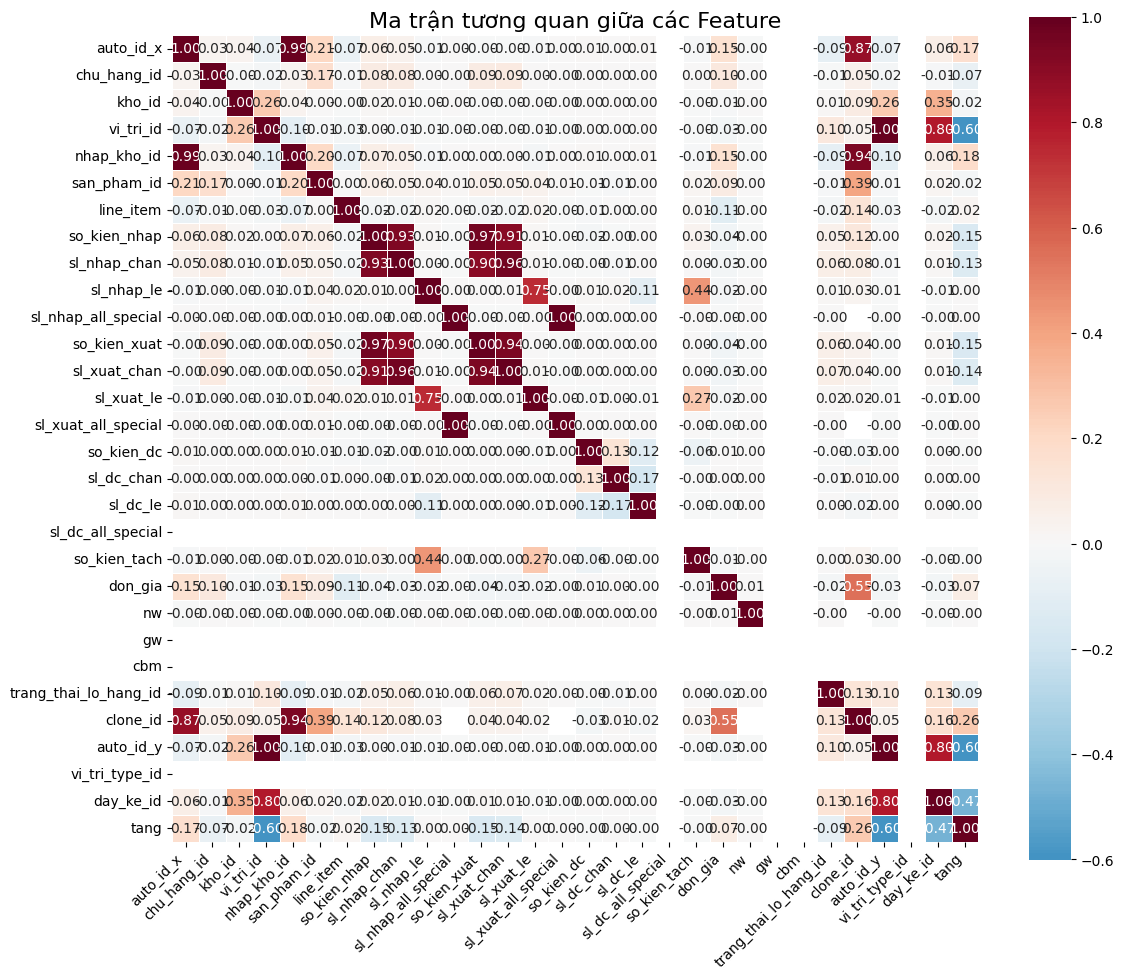

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chỉ lấy các cột số
corr = feature_table.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,          # Hiển thị hệ số tương quan
    fmt=".2f",
    cmap="RdBu_r",       # Đỏ: tương quan dương, Xanh: tương quan âm
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Ma trận tương quan giữa các Feature", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
corr["day_ke_id"].sort_values(ascending=False)

day_ke_id                1.000000
vi_tri_id                0.795544
auto_id_y                0.795544
kho_id                   0.352072
clone_id                 0.162506
trang_thai_lo_hang_id    0.131483
auto_id_x                0.064250
nhap_kho_id              0.059614
so_kien_nhap             0.020620
san_pham_id              0.020218
so_kien_xuat             0.013028
sl_xuat_chan             0.008855
sl_nhap_chan             0.007886
sl_dc_le                 0.001619
so_kien_dc               0.001372
sl_dc_chan               0.000528
nw                      -0.000586
sl_nhap_all_special     -0.000586
sl_xuat_all_special     -0.000586
so_kien_tach            -0.004041
sl_nhap_le              -0.005469
sl_xuat_le              -0.005998
chu_hang_id             -0.010141
line_item               -0.023835
don_gia                 -0.028118
tang                    -0.469298
sl_dc_all_special             NaN
gw                            NaN
cbm                           NaN
vi_tri_type_id

In [ ]:
corr["tang"].sort_values(ascending=False)

tang                     1.000000
clone_id                 0.258196
nhap_kho_id              0.182975
auto_id_x                0.168261
don_gia                  0.070055
line_item                0.022329
sl_xuat_le               0.003255
sl_dc_chan               0.000942
sl_nhap_all_special      0.000940
sl_xuat_all_special      0.000940
sl_nhap_le               0.000463
nw                      -0.000049
so_kien_dc              -0.001604
sl_dc_le                -0.001770
so_kien_tach            -0.003974
kho_id                  -0.016152
san_pham_id             -0.022110
chu_hang_id             -0.070038
trang_thai_lo_hang_id   -0.088287
sl_nhap_chan            -0.132894
sl_xuat_chan            -0.137817
so_kien_xuat            -0.149655
so_kien_nhap            -0.149834
day_ke_id               -0.469298
auto_id_y               -0.600512
vi_tri_id               -0.600512
sl_dc_all_special             NaN
gw                            NaN
cbm                           NaN
vi_tri_type_id

In [ ]:
# from pathlib import Path

# output_dir = Path("../data/process")
# output_dir.mkdir(parents=True, exist_ok=True)

# feature_table.to_csv(
#     output_dir / "feature_new.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("Đã lưu:", output_dir / "feature_new.csv")

## Merge data để train 

In [ ]:
import pandas as pd

feature_new = pd.read_csv("../data/process/feature_new.csv")
rules_train = pd.read_csv("../data/process/rules_train.csv")

C:\Users\anhkh\AppData\Local\Temp\ipykernel_13364\236391906.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  feature_new = pd.read_csv("../data/process/feature_new.csv")


In [ ]:
dataset = feature_new.merge(
    rules_train,
    on="san_pham_id",
    how="inner"
)

In [ ]:
warehouse_map = {
    12473657: "1",
    12630830: "3",
    12630825: "2"
}

dataset["warehouse_id"] = (
    dataset["kho_id"]
    .map(warehouse_map)
)

In [ ]:
abc_map = {
    "A":3,
    "B":2,
    "C":1
}

dataset["abc_score"] = (
    dataset["abc_class"]
    .map(abc_map)
)

In [ ]:
dataset.head(20)

,san_pham_id,nganh_hang_id,gw_san_pham,cbm_san_pham,so_ngay_su_dung,tong_nhap,ton_kho,tong_xuat,tan_suat_xuat,abc_class,...,remaining_shelf_life_days,inventory_age_days,inventory_turnover,kho_id,so_day,day_chinh,ty_le,so_tang,tang_chinh,warehouse_id
0,20003159.0,12501018.0,5.8,13700.500,0.0,40.0,0.0,56.0,7.0,C,...,0.000000,376.000000,0.000000,12473657,4,12473743,25.00,3,3,1
1,12504099.0,12501018.0,5.8,14256.000,0.0,200.0,0.0,256.0,21.0,C,...,0.000000,351.333333,0.000000,12473657,4,12473743,33.33,4,0,1
2,12504065.0,12501018.0,9.0,19600.000,1096.0,1308.0,48.0,1314.0,94.0,C,...,1026.055556,234.100000,27.375000,12473657,7,12473743,37.50,6,0,1
3,12504075.0,12501018.0,9.0,18483.750,1096.0,924.0,210.0,372.0,34.0,C,...,1009.750000,347.200000,1.771429,12473657,8,12473743,23.53,8,5,1
4,12505475.0,12501018.0,10.5,28927.500,1096.0,16380.0,1656.0,10764.0,269.0,B,...,1094.862069,232.823529,6.500000,12473657,13,12473779,22.73,10,5,1
5,12505475.0,12501018.0,10.5,28927.500,1096.0,16380.0,1656.0,10764.0,269.0,B,...,1094.862069,232.823529,6.500000,12630830,1,49647766,100.00,1,0,3
6,12505495.0,12501018.0,8.0,22500.000,1096.0,1728.0,360.0,720.0,20.0,C,...,1072.727273,150.727273,2.000000,12473657,6,12473743,45.45,6,0,1
7,12505495.0,12501018.0,8.0,22500.000,1096.0,1728.0,360.0,720.0,20.0,C,...,1072.727273,150.727273,2.000000,12630830,1,49647766,100.00,1,0,3
8,12501115.0,12501020.0,12.0,33214.000,730.0,2772.0,174.0,1860.0,156.0,C,...,689.214286,256.285714,10.689655,12473657,7,12473765,45.45,7,0,1
9,12503889.0,12501016.0,3.8,37740.000,0.0,6756.0,684.0,4832.0,281.0,B,...,1684.000000,289.285714,7.064327,12473657,8,12473791,30.00,8,0,1


In [ ]:
# from pathlib import Path

# output_dir = Path("../data/process")
# output_dir.mkdir(parents=True, exist_ok=True)

# dataset.to_csv(
#     output_dir / "dataset.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("Đã lưu:", output_dir / "fdataset.csv")

In [ ]:
print(feature_new["san_pham_id"].nunique())
print(rules_train["san_pham_id"].nunique())
tonkho["san_pham_id"].nunique()
tonkho["san_pham_id"].count()

348316
8339


692652

In [ ]:
print(tonkho["san_pham_id"].nunique())

8339


In [ ]:
reserve = tonkho.merge(
    vitri[["auto_id", "vi_tri_type_id", "day_ke_id", "tang"]],
    left_on = "vi_tri_id",
    right_on = "auto_id",
    how="left"
)

reserve = reserve[reserve["vi_tri_type_id"] == 2]

In [ ]:
reserve.columns

Index(['auto_id_x', 'chu_hang_id', 'kho_id', 'vi_tri_id', 'so_lpn',
       'nhap_kho_id', 'san_pham_id', 'so_po', 'ngay_san_xuat', 'ngay_het_han',
       'line_item', 'ma_key_lo_hang', 'ngay_nhap_kho_root', 'so_kien_nhap',
       'sl_nhap_chan', 'sl_nhap_le', 'sl_nhap_all_special', 'so_kien_xuat',
       'sl_xuat_chan', 'sl_xuat_le', 'sl_xuat_all_special', 'so_kien_dc',
       'sl_dc_chan', 'sl_dc_le', 'sl_dc_all_special', 'so_kien_tach',
       'don_gia', 'nw', 'gw', 'cbm', 'trang_thai_lo_hang_id', 'clone_id',
       'auto_id_y', 'vi_tri_type_id', 'day_ke_id', 'tang'],
      dtype='object')

In [ ]:
print(reserve.columns.tolist())
print(feature_new.columns.tolist())

['auto_id_x', 'chu_hang_id', 'kho_id', 'vi_tri_id', 'so_lpn', 'nhap_kho_id', 'san_pham_id', 'so_po', 'ngay_san_xuat', 'ngay_het_han', 'line_item', 'ma_key_lo_hang', 'ngay_nhap_kho_root', 'so_kien_nhap', 'sl_nhap_chan', 'sl_nhap_le', 'sl_nhap_all_special', 'so_kien_xuat', 'sl_xuat_chan', 'sl_xuat_le', 'sl_xuat_all_special', 'so_kien_dc', 'sl_dc_chan', 'sl_dc_le', 'sl_dc_all_special', 'so_kien_tach', 'don_gia', 'nw', 'gw', 'cbm', 'trang_thai_lo_hang_id', 'clone_id', 'auto_id_y', 'vi_tri_type_id', 'day_ke_id', 'tang']
['san_pham_id', 'nganh_hang_id', 'gw_san_pham', 'cbm_san_pham', 'so_ngay_su_dung', 'tong_nhap', 'ton_kho', 'tong_xuat', 'tan_suat_xuat', 'abc_class', 'abc_score', 'ti_le_cham_hang', 'shelf_life_days', 'remaining_shelf_life_days', 'inventory_age_days', 'inventory_turnover']


In [ ]:
df = reserve.merge(
    feature_new,
    on=["san_pham_id"],
    how="left"
)

In [ ]:
df.columns

Index(['auto_id_x', 'chu_hang_id', 'kho_id', 'vi_tri_id', 'so_lpn',
       'nhap_kho_id', 'san_pham_id', 'so_po', 'ngay_san_xuat', 'ngay_het_han',
       'line_item', 'ma_key_lo_hang', 'ngay_nhap_kho_root', 'so_kien_nhap',
       'sl_nhap_chan', 'sl_nhap_le', 'sl_nhap_all_special', 'so_kien_xuat',
       'sl_xuat_chan', 'sl_xuat_le', 'sl_xuat_all_special', 'so_kien_dc',
       'sl_dc_chan', 'sl_dc_le', 'sl_dc_all_special', 'so_kien_tach',
       'don_gia', 'nw', 'gw', 'cbm', 'trang_thai_lo_hang_id', 'clone_id',
       'auto_id_y', 'vi_tri_type_id', 'day_ke_id', 'tang', 'nganh_hang_id',
       'gw_san_pham', 'cbm_san_pham', 'so_ngay_su_dung', 'tong_nhap',
       'ton_kho', 'tong_xuat', 'tan_suat_xuat', 'abc_class', 'abc_score',
       'ti_le_cham_hang', 'shelf_life_days', 'remaining_shelf_life_days',
       'inventory_age_days', 'inventory_turnover', 'reserve_day',
       'reserve_tang'],
      dtype='object')

In [ ]:
df["reserve_day"] = df["day_ke_id"]
df["reserve_tang"] = df["tang"]
df["reserve_vitri"] = df["vi_tri_id"]

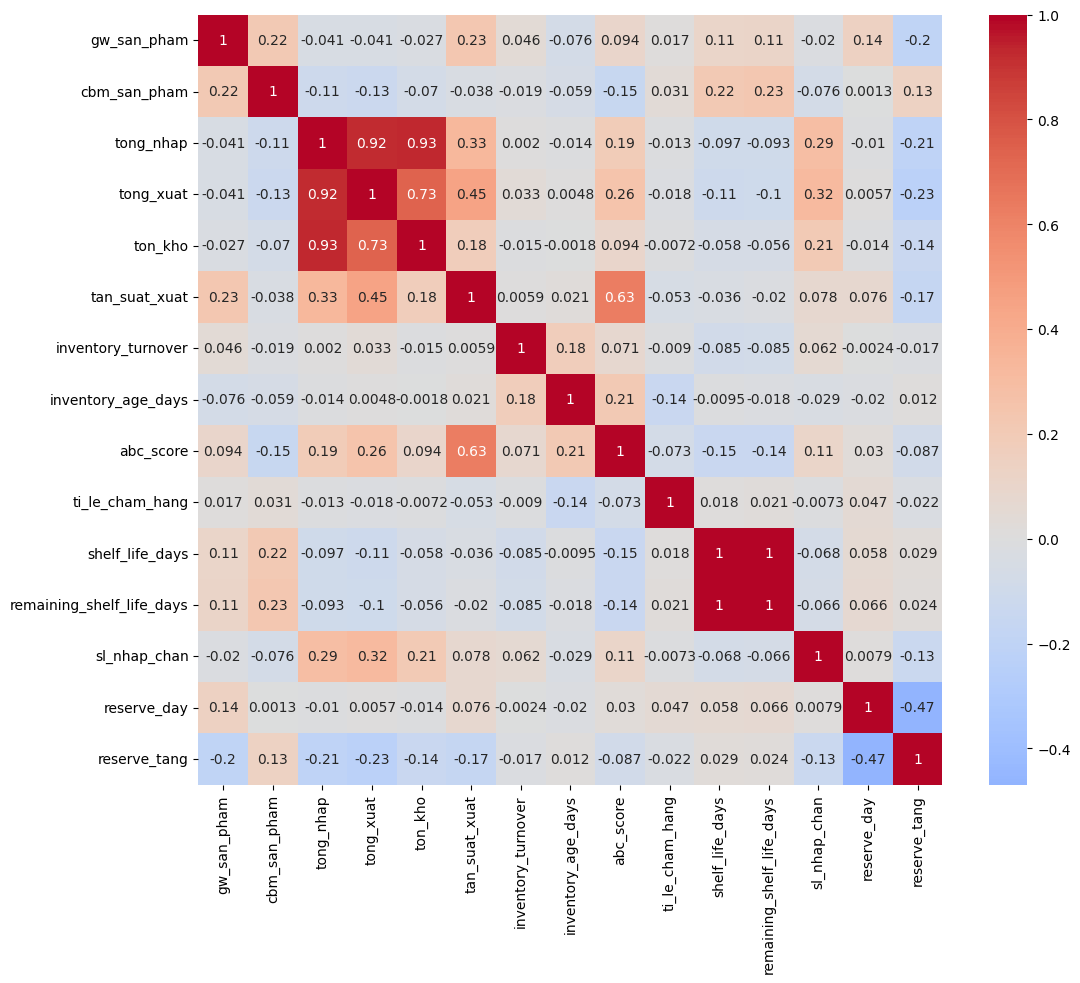

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    "gw_san_pham",
    "cbm_san_pham",
    "tong_nhap",
    "tong_xuat",
    "ton_kho",
    "tan_suat_xuat",
    "inventory_turnover",
    "inventory_age_days",
    "abc_score",
    "ti_le_cham_hang",
    "shelf_life_days",
    "remaining_shelf_life_days",
    "sl_nhap_chan",
    "reserve_day",
    "reserve_tang",

]

corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.show()

In [ ]:
corr["reserve_day"].sort_values(ascending=False)

reserve_day                  1.000000
gw_san_pham                  0.139267
tan_suat_xuat                0.075887
remaining_shelf_life_days    0.065710
shelf_life_days              0.057779
ti_le_cham_hang              0.047320
abc_score                    0.029614
sl_nhap_chan                 0.007886
tong_xuat                    0.005747
cbm_san_pham                 0.001269
inventory_turnover          -0.002403
tong_nhap                   -0.009979
ton_kho                     -0.013576
inventory_age_days          -0.020373
reserve_tang                -0.469298
Name: reserve_day, dtype: float64

In [ ]:
corr["reserve_tang"].sort_values(ascending=False)

reserve_tang          1.000000
cbm_san_pham          0.134751
inventory_age_days    0.012408
inventory_turnover   -0.016763
abc_score            -0.086759
ton_kho              -0.142906
tan_suat_xuat        -0.166435
gw_san_pham          -0.198581
tong_nhap            -0.206152
tong_xuat            -0.231546
reserve_day          -0.469298
reserve_vitri        -0.600512
Name: reserve_tang, dtype: float64

In [ ]:
df.groupby("reserve_day")["gw_san_pham"].mean().sort_index()

reserve_day
12473743     8.064053
12473745    10.577682
12473747    10.401867
12473749    10.391222
12473751    10.230174
12473753     9.225719
12473755     9.651281
12473757    10.174000
12473759    10.508897
12473761     4.818942
12473763     9.896449
12473765     7.805572
12473767     8.489214
12473769     9.204150
12473771     8.526246
12473773     9.936931
12473775    11.648171
12473777    10.633179
12473779    11.125648
12473781    10.251572
12473783    10.793564
12473785    10.742173
12473787    10.349125
12473789    10.683100
12473791    10.120387
12473793    10.253072
12473795     9.776285
12473807    12.234396
14022647     3.525000
23283163    14.267546
49647682    10.654000
49647684     9.569500
49647704     7.800000
52188579    16.600000
52188609    17.000000
52188611    17.000000
52188615    17.000000
52188621    13.200000
52188625    17.000000
52188627    17.100000
52188629    13.200000
52188631    13.200000
52188637    13.200000
52188639    14.466667
52188641    15.00000

In [ ]:
df.groupby("reserve_day")["tan_suat_xuat"].mean().sort_index()

reserve_day
12473743     381.787759
12473745     849.856451
12473747     851.822228
12473749     811.274432
12473751     772.884481
12473753     832.637073
12473755     866.081739
12473757     858.468656
12473759     865.344320
12473761     190.135612
12473763     237.932531
12473765     379.278520
12473767     449.600857
12473769     475.738041
12473771     464.849977
12473773     506.768799
12473775     544.482710
12473777     448.371134
12473779     451.840601
12473781     428.953852
12473783     507.463565
12473785     421.666228
12473787     412.546362
12473789     440.754289
12473791     545.945097
12473793     499.265343
12473795     485.994342
12473807    1235.261858
14022647     418.000000
23283163     824.577471
49647682     407.222222
49647684     397.000000
49647704     582.000000
52188579    1200.000000
52188609     820.000000
52188611     820.000000
52188615     820.000000
52188621     496.000000
52188625     280.500000
52188627     648.000000
52188629     496.000000
5218

In [ ]:
pd.crosstab(df["reserve_day"], df["abc_class"], normalize="index")

abc_class,0,A,B,C
reserve_day,,,,
12473743,0.000415,0.293983,0.262863,0.442739
12473745,0.011889,0.767063,0.152356,0.068692
12473747,0.009098,0.757807,0.167937,0.065159
12473749,0.008144,0.737414,0.179911,0.074531
12473751,0.007773,0.727419,0.194854,0.069954
12473753,0.007561,0.768293,0.160000,0.064146
12473755,0.007108,0.755057,0.153909,0.083926
12473757,0.017179,0.761905,0.157022,0.063894
12473759,0.012360,0.775750,0.159506,0.052384


In [ ]:
from sklearn.feature_selection import mutual_info_classif

X = df[feature_table]
y = df["reserve_day"]

mi = mutual_info_classif(X, y, random_state=42)

pd.Series(mi, index=feature_table).sort_values(ascending=False)

ValueError: Boolean array expected for the condition, not float64